# 🤖 Attention Is All You Need — PyTorch 구현 스터디 노트

> Vaswani et al., 2017 | [논문 링크](https://arxiv.org/abs/1706.03762)

각 셀마다 **텐서의 shape 변화를 직접 출력**하며 Transformer의 동작 원리를 확인한다.

---

### 목차
1. 환경 설정 & 하이퍼파라미터
2. 입력 임베딩 & Positional Encoding
3. Scaled Dot-Product Attention
4. Multi-Head Attention
5. Feed-Forward Network
6. Encoder Layer (Add & Norm 포함)
7. Decoder Layer (Masked + Cross Attention)
8. Encoder / Decoder 전체 스택
9. 마스크 생성 유틸리티
10. Transformer 전체 모델
11. 학습 루프 미니 예시


## 1. 환경 설정 & 하이퍼파라미터

### 📌 논문 Table 1 — Model Configurations

| 파라미터 | 의미 | Base | Big |
|----------|------|------|-----|
| `d_model` | 임베딩/모델 전체 차원 | 512 | 1024 |
| `num_heads` | 어텐션 헤드 수 | 8 | 16 |
| `num_layers` N | Encoder·Decoder 레이어 수 | 6 | 6 |
| `d_ff` | FFN 내부 은닉 차원 (≈ 4×d_model) | 2048 | 4096 |
| `dropout` | 드롭아웃 비율 | 0.1 | 0.3 |
| `warmup_steps` | Noam 스케줄러 워밍업 스텝 수 | 4000 | 4000 |

In [108]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)  # 재현성을 위한 시드 고정

# ┌─────────────────────────────────────────────────────────────────────┐
# │                    하이퍼파라미터 설정                                   │
# │  왼쪽 = Study 값 (shape 추적용 작은 수)                                  │
# │  오른쪽 주석 = 논문 Base Model 값 (Table 1)                             │
# └─────────────────────────────────────────────────────────────────────┘

# ── 모델 구조 파라미터 (논문 Section 3.1, Table 1) ────────────────────
D_MODEL    = 16      # 논문: 512  | 임베딩·모델 전체 차원. d_k = D_MODEL / NUM_HEADS
NUM_HEADS  = 2       # 논문: 8   | 어텐션 헤드 수. D_MODEL % NUM_HEADS == 0 이어야 함
NUM_LAYERS = 2       # 논문: 6   | Encoder & Decoder 레이어 반복 횟수 N
D_FF       = 32      # 논문: 2048 | FFN 내부 은닉 차원. 논문은 D_MODEL × 4 사용

# ── 정규화 파라미터 (논문 Section 5.4) ───────────────────────────────
DROPOUT    = 0.0     # 논문: 0.1  | 학습 시 드롭아웃 비율. 0.0 = shape 확인용 (비활성)

# ── 학습 파라미터 (논문 Section 5.3) ─────────────────────────────────
WARMUP_STEPS = 4000  # 논문: 4000 | Noam 스케줄러 선형 증가 구간 스텝 수
BETA1      = 0.9     # 논문: 0.9  | Adam 1차 모멘텀 계수
BETA2      = 0.98    # 논문: 0.98 | Adam 2차 모멘텀 계수
EPS        = 1e-9    # 논문: 1e-9 | Adam 수치 안정성 항
LABEL_SMOOTH = 0.1   # 논문: 0.1  | Label Smoothing (Cross-Entropy 내 적용)

# ── 어휘 & 패딩 설정 ─────────────────────────────────────────────────
SRC_VOCAB  = 100     # 논문: ~37000 (WMT EN-DE BPE 기준) | 소스 어휘 크기
TGT_VOCAB  = 100     # 논문: ~37000                       | 타겟 어휘 크기
PAD_IDX    = 0       # 논문: 0 | <PAD> 토큰 인덱스 (어텐션·Loss에서 무시)

# ── 더미 배치 설정 (shape 추적용) ────────────────────────────────────
BATCH      = 2       # 논문: 25000 tokens/batch | 미니배치 크기
SRC_LEN    = 6       # 논문: 최대 수백 토큰     | 소스 시퀀스 길이
TGT_LEN    = 5       # 논문: 최대 수백 토큰     | 타겟 시퀀스 길이

# ── 디바이스 설정 ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 파생 값 출력 (설정 확인) ─────────────────────────────────────────
D_K = D_MODEL // NUM_HEADS  # 헤드 당 차원 (논문: 512/8 = 64)
print('=' * 55)
print(f'  {"파라미터":<20} {"Study 값":>10}   {"논문 Base":>10}')
print('=' * 55)
print(f'  {"D_MODEL":<20} {D_MODEL:>10}   {"512":>10}')
print(f'  {"NUM_HEADS":<20} {NUM_HEADS:>10}   {"8":>10}')
print(f'  {"d_k = D_MODEL/h":<20} {D_K:>10}   {"64":>10}')
print(f'  {"NUM_LAYERS (N)":<20} {NUM_LAYERS:>10}   {"6":>10}')
print(f'  {"D_FF":<20} {D_FF:>10}   {"2048":>10}')
print(f'  {"DROPOUT":<20} {DROPOUT:>10}   {"0.1":>10}')
print(f'  {"SRC_VOCAB":<20} {SRC_VOCAB:>10}   {"~37000":>10}')
print(f'  {"BATCH":<20} {BATCH:>10}   {"~25k tok":>10}')
print(f'  {"SRC_LEN":<20} {SRC_LEN:>10}   {"수백":>10}')
print('=' * 55)
print(f'  디바이스: {device}')
assert D_MODEL % NUM_HEADS == 0, 'D_MODEL은 NUM_HEADS로 나누어 떨어져야 함!'
print('  ✅ D_MODEL % NUM_HEADS == 0  조건 통과')

  파라미터                    Study 값      논문 Base
  D_MODEL                      16          512
  NUM_HEADS                     2            8
  d_k = D_MODEL/h               8           64
  NUM_LAYERS (N)                2            6
  D_FF                         32         2048
  DROPOUT                     0.0          0.1
  SRC_VOCAB                   100       ~37000
  BATCH                         2     ~25k tok
  SRC_LEN                       6           수백
  디바이스: cpu
  ✅ D_MODEL % NUM_HEADS == 0  조건 통과


## 2. 입력 임베딩 & Positional Encoding

### 📌 논문 Section 3.4, 3.5

- **Token Embedding**: 정수 인덱스 → d_model 차원 밀집 벡터  
- **Positional Encoding**: 순서 정보가 없는 Self-Attention을 보완하기 위해 위치 정보를 임베딩에 더함

$$PE_{(pos,\ 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
PE_{(pos,\ 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$


In [109]:
# ── 더미 소스 시퀀스 (정수 토큰 인덱스) ──────────────────
# torch.randint(low, high, size): [low, high) 범위의 정수 텐서 생성
# PAD(=0)를 제외하기 위해 1부터 시작
src_tokens = torch.randint(1, SRC_VOCAB, (BATCH, SRC_LEN))
print("▶ 입력 토큰 인덱스")
print(f"  src_tokens.shape : {src_tokens.shape}")   # (2, 10)
print(f"  dtype            : {src_tokens.dtype}")
print(f"  값 예시          : {src_tokens[0].tolist()}")


▶ 입력 토큰 인덱스
  src_tokens.shape : torch.Size([2, 6])
  dtype            : torch.int64
  값 예시          : [7, 96, 98, 59, 91, 66]


In [110]:
# ── Token Embedding ───────────────────────────────────────
# nn.Embedding(vocab_size, d_model):
#   정수 인덱스를 d_model 차원 벡터로 변환하는 lookup table
#   내부적으로 (vocab_size × d_model) 행렬을 유지
embedding = nn.Embedding(SRC_VOCAB, D_MODEL)

embedded = embedding(src_tokens)           # (B, S, D_MODEL)
print("▶ Token Embedding 후")
print(f"  embedded.shape : {embedded.shape}")   # (2, 10, 512)

# 논문 Section 3.4: 임베딩에 sqrt(d_model)을 곱해 스케일 조정
#   → PE의 크기와 임베딩 크기를 맞춰 PE 신호가 묻히지 않게 함
scale = math.sqrt(D_MODEL)
embedded_scaled = embedded * scale
print(f"  스케일링 전 평균: {embedded.mean().item():.4f}")
print(f"  스케일링 후 평균: {embedded_scaled.mean().item():.4f}  (× {scale:.1f})")


▶ Token Embedding 후
  embedded.shape : torch.Size([2, 6, 16])
  스케일링 전 평균: 0.0225
  스케일링 후 평균: 0.0900  (× 4.0)


In [111]:
# ── Positional Encoding ───────────────────────────────────
class PositionalEncoding(nn.Module):
    """
    논문 Section 3.5, Equation (3)(4)

    register_buffer:
        - 학습 파라미터(requires_grad=False)가 아닌 텐서를 모듈에 등록
        - model.to(device) 호출 시 자동으로 같은 device로 이동
        - state_dict에 포함되어 저장/로드됨
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)          # (max_len, d_model)

        # position: (max_len, 1) 열벡터 — pos 값
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # div_term: 10000^(2i/d_model) 분모를 log-space에서 계산 (수치 안정성)
        # torch.arange(0, d_model, 2): [0, 2, 4, ..., d_model-2]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스: cos

        pe = pe.unsqueeze(0)                          # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # [broadcast 예시] 배치 차원 자동 확장
        #   x        : (2, 6, 16)  ← (B, S, D_MODEL)
        #   pe[:, :S]: (1, 6, 16)  ← (1, S, D_MODEL)
        #   결과     : (2, 6, 16)  ← 1 → B 로 확장
        # x: (B, S, D_MODEL)
        # self.pe[:, :S]: 현재 길이만큼만 슬라이싱 후 더함
        x = x + self.pe[:, :x.size(1)].detach()
        return self.dropout(x)

pos_enc = PositionalEncoding(D_MODEL, dropout=0.0)  # dropout=0 → shape 확인 목적

print("▶ Positional Encoding 버퍼 shape:", pos_enc.pe.shape)  # (1, 5000, 512)

x_after_pe = pos_enc(embedded_scaled)
print("▶ PE 적용 후 shape:", x_after_pe.shape)               # (2, 10, 512)

# PE 값 시각적 확인: pos=0,1,2의 처음 8개 차원
print("\n▶ PE 값 샘플 (처음 3개 위치, 처음 8개 차원):")
for pos in range(3):
    vals = pos_enc.pe[0, pos, :8].tolist()
    print(f"  pos={pos}: {[f'{v:.3f}' for v in vals]}")


▶ Positional Encoding 버퍼 shape: torch.Size([1, 5000, 16])
▶ PE 적용 후 shape: torch.Size([2, 6, 16])

▶ PE 값 샘플 (처음 3개 위치, 처음 8개 차원):
  pos=0: ['0.000', '1.000', '0.000', '1.000', '0.000', '1.000', '0.000', '1.000']
  pos=1: ['0.841', '0.540', '0.311', '0.950', '0.100', '0.995', '0.032', '1.000']
  pos=2: ['0.909', '-0.416', '0.591', '0.807', '0.199', '0.980', '0.063', '0.998']


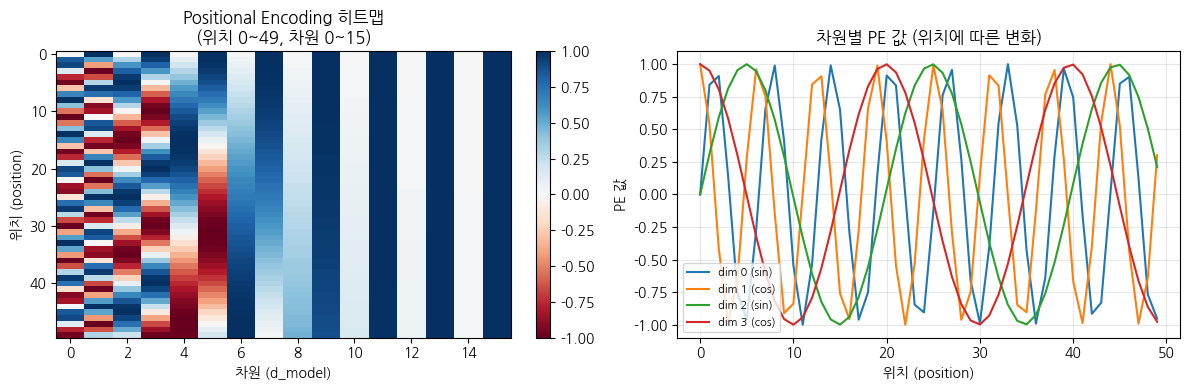

▶ PE 저장: figures/positional_encoding.png


In [112]:
# ── Positional Encoding 히트맵 시각화 ────────────────────
# pe[0]: (max_len, d_model) — 위치별 인코딩 패턴 확인
import os; os.makedirs("figures", exist_ok=True)

pe_values = pos_enc.pe[0, :50, :].detach().numpy()   # 처음 50개 위치만 표시

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 전체 히트맵
im = axes[0].imshow(pe_values, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title(f'Positional Encoding 히트맵\n(위치 0~49, 차원 0~{D_MODEL-1})')
axes[0].set_xlabel('차원 (d_model)')
axes[0].set_ylabel('위치 (position)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# 오른쪽: 특정 차원의 sin/cos 곡선
positions = list(range(50))
for dim, label in [(0, 'dim 0 (sin)'), (1, 'dim 1 (cos)'), (2, 'dim 2 (sin)'), (3, 'dim 3 (cos)')]:
    if dim < D_MODEL:
        axes[1].plot(positions, pe_values[:, dim], label=label)
axes[1].set_title('차원별 PE 값 (위치에 따른 변화)')
axes[1].set_xlabel('위치 (position)')
axes[1].set_ylabel('PE 값')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/positional_encoding.png", dpi=100)
plt.show()
print("▶ PE 저장: figures/positional_encoding.png")


## 3. Scaled Dot-Product Attention

### 📌 논문 Section 3.2.1, Equation (1)

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| 변수 | 의미 | shape |
|------|------|-------|
| Q | Query | (..., seq_q, d_k) |
| K | Key   | (..., seq_k, d_k) |
| V | Value | (..., seq_k, d_v) |
| 출력 | Attention-weighted sum | (..., seq_q, d_v) |


In [113]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    print(f"  [내부] Q:{Q.shape}  K:{K.shape}  V:{V.shape}  d_k={d_k}")

    # ── Step 1: QKᵀ / √d_k ────────────────────────────────
    # [broadcast 예시] 스칼라를 텐서 전체에 적용
    #   scores      : (2, 6, 6)  ← 임의 shape
    #   math.sqrt() : scalar
    #   결과        : (2, 6, 6)  ← 모든 원소에 동일하게 나눔
    # K.transpose(-2, -1): 마지막 두 차원을 전치 (seq_k, d_k) → (d_k, seq_k)
    # torch.matmul: 배치 차원은 그대로 두고 마지막 두 차원에 행렬 곱
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    print(f"  [내부] scores (QKᵀ/√dk): {scores.shape}")  # (..., seq_q, seq_k)

    # ── Step 2: 마스킹 (선택) ─────────────────────────────
    if mask is not None:
        # masked_fill(mask, value): mask=True 위치를 value로 채움
        # -1e9 → softmax 후 ≈ 0 이 됨
        scores = scores.masked_fill(mask, -1e9)
        print(f"  [내부] 마스크 적용 완료")

    # ── Step 3: Softmax → 어텐션 가중치 ───────────────────
    # dim=-1: key 차원(마지막)에 대해 softmax → 행의 합 = 1
    attn_weights = F.softmax(scores, dim=-1)
    print(f"  [내부] attn_weights: {attn_weights.shape}  합 샘플={attn_weights[0,0].sum():.4f}")

    # ── Step 4: 가중 합계 ─────────────────────────────────
    output = torch.matmul(attn_weights, V)
    print(f"  [내부] output: {output.shape}")

    return output, attn_weights

# ── 단일 헤드 테스트 (d_k = 64) ──────────────────────────
d_k = D_MODEL // NUM_HEADS   # 64
seq_q, seq_k = SRC_LEN, SRC_LEN

Q_test = torch.randn(BATCH, seq_q, d_k)
K_test = torch.randn(BATCH, seq_k, d_k)
V_test = torch.randn(BATCH, seq_k, d_k)

print("▶ Scaled Dot-Product Attention 실행:")
out, weights = scaled_dot_product_attention(Q_test, K_test, V_test)
print(f"\n▶ 최종 출력 shape : {out.shape}")       # (2, 10, 64)
print(f"▶ 가중치 shape    : {weights.shape}")     # (2, 10, 10)


▶ Scaled Dot-Product Attention 실행:
  [내부] Q:torch.Size([2, 6, 8])  K:torch.Size([2, 6, 8])  V:torch.Size([2, 6, 8])  d_k=8
  [내부] scores (QKᵀ/√dk): torch.Size([2, 6, 6])
  [내부] attn_weights: torch.Size([2, 6, 6])  합 샘플=1.0000
  [내부] output: torch.Size([2, 6, 8])

▶ 최종 출력 shape : torch.Size([2, 6, 8])
▶ 가중치 shape    : torch.Size([2, 6, 6])


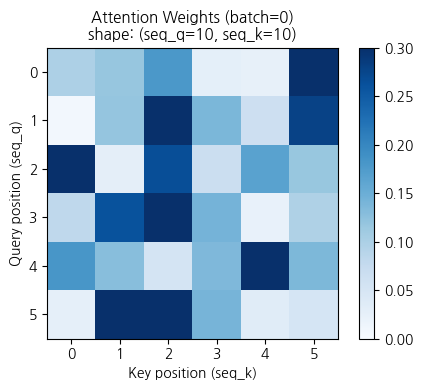

▶ 각 행의 합 (≈ 1.0): [1.0000001192092896, 1.0, 0.9999999403953552, 0.9999999403953552, 1.0, 1.0]


In [114]:
# ── 어텐션 가중치 히트맵 시각적 확인 ────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights[0].detach().numpy(), cmap='Blues', vmin=0, vmax=0.3)
ax.set_title("Attention Weights (batch=0)\nshape: (seq_q=10, seq_k=10)", fontsize=11)
ax.set_xlabel("Key position (seq_k)")
ax.set_ylabel("Query position (seq_q)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
plt.savefig("figures/attn_weights.png", dpi=100)
plt.show()
print("▶ 각 행의 합 (≈ 1.0):", weights[0].sum(dim=-1).tolist())


## 4. Multi-Head Attention

### 📌 논문 Section 3.2.2, Equation (4)(5)

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$
$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

단일 어텐션 대신 **h개의 헤드를 병렬로 실행**해 서로 다른 표현 부분공간 정보를 포착한다.

**텐서 변환 흐름:**
```
(B, S, D_MODEL)
    → 선형 투영 W^Q/K/V
    → (B, S, D_MODEL)
    → split_heads (view + transpose)
    → (B, h, S, d_k)        ← 헤드 차원이 배치처럼 처리됨
    → Scaled Dot-Product Attention
    → (B, h, S, d_k)
    → transpose + view (헤드 결합)
    → (B, S, D_MODEL)
    → 선형 투영 W^O
    → (B, S, D_MODEL)
```


In [115]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads

        # 각 헤드에 대한 W^Q, W^K, W^V를 하나의 큰 행렬로 합쳐서 처리
        # nn.Linear(in, out): y = xWᵀ + b
        self.W_q = nn.Linear(d_model, d_model)   # W^Q
        self.W_k = nn.Linear(d_model, d_model)   # W^K
        self.W_v = nn.Linear(d_model, d_model)   # W^V
        self.W_o = nn.Linear(d_model, d_model)   # W^O

    def split_heads(self, x, label=""):
        """
        (B, S, D_MODEL) → (B, h, S, d_k)
        
        view: shape만 바꿈 (메모리 공유, contiguous 텐서에서만 동작)
        transpose: 차원 순서 변경 (메모리 비연속 → 이후 contiguous 필요)
        """
        B, S, _ = x.size()
        x = x.view(B, S, self.num_heads, self.d_k)   # (B, S, h, d_k)
        x = x.transpose(1, 2)                         # (B, h, S, d_k)
        if label:
            print(f"    split_heads [{label}]: (B,S,D)→(B,h,S,dk) = {x.shape}")
        return x

    def forward(self, Q, K, V, mask=None, verbose=False):
        B = Q.size(0)

        if verbose:
            print(f"  입력  Q:{Q.shape}  K:{K.shape}  V:{V.shape}")

        # ── 선형 투영 + 헤드 분리 ────────────────────────
        Q = self.split_heads(self.W_q(Q), "Q" if verbose else "")
        K = self.split_heads(self.W_k(K), "K" if verbose else "")
        V = self.split_heads(self.W_v(V), "V" if verbose else "")

        # ── 마스크 차원 조정: (B,1,1,seq_k) → h 헤드에 브로드캐스팅 ──
        # [broadcast 예시] h 차원 자동 확장
        #   scores : (2, 2, 6, 6)  ← (B, h, seq_q, seq_k)
        #   mask   : (2, 1, 1, 6)  ← (B, 1,  1,    seq_k)
        #   결과   : (2, 2, 6, 6)  ← h·seq_q 차원으로 확장
        if mask is not None:
            mask = mask.unsqueeze(1)

        # ── Scaled Dot-Product Attention ─────────────────
        # verbose=False: 내부 print 생략
        attn_out, attn_weights = scaled_dot_product_attention.__wrapped__(Q, K, V, mask)             if hasattr(scaled_dot_product_attention, '__wrapped__')             else _sdpa_quiet(Q, K, V, mask)

        if verbose:
            print(f"  어텐션 후 shape: {attn_out.shape}")  # (B, h, S, d_k)

        # ── 헤드 결합: (B,h,S,dk) → (B,S,D_MODEL) ───────
        # transpose(1,2): (B,h,S,dk) → (B,S,h,dk)
        # contiguous(): transpose 후 메모리 비연속 상태 해소 (view 사용 전 필수)
        # view(B, -1, d_model): (B,S,h,dk) → (B,S,D_MODEL)  (-1은 자동 추론)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        if verbose:
            print(f"  헤드 결합 후 shape: {attn_out.shape}")  # (B, S, D_MODEL)

        output = self.W_o(attn_out)
        if verbose:
            print(f"  W^O 투영 후 shape: {output.shape}")  # (B, S, D_MODEL)

        return output, attn_weights

# ── 조용한 버전의 SDPA (verbose 없이 사용) ────────────────
def _sdpa_quiet(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, -1e9)
    attn_weights = F.softmax(scores, dim=-1)
    return torch.matmul(attn_weights, V), attn_weights

print("▶ MultiHeadAttention 테스트 (verbose=True):")
mha = MultiHeadAttention(D_MODEL, NUM_HEADS)
x_in = torch.randn(BATCH, SRC_LEN, D_MODEL)
out_mha, w_mha = mha(x_in, x_in, x_in, verbose=True)
print(f"\n▶ 최종 출력 shape: {out_mha.shape}")       # (2, 10, 512)
print(f"▶ 어텐션 가중치 shape: {w_mha.shape}")       # (2, 8, 10, 10)
print(f"   └─ (batch={BATCH}, heads={NUM_HEADS}, seq_q={SRC_LEN}, seq_k={SRC_LEN})")


▶ MultiHeadAttention 테스트 (verbose=True):
  입력  Q:torch.Size([2, 6, 16])  K:torch.Size([2, 6, 16])  V:torch.Size([2, 6, 16])
    split_heads [Q]: (B,S,D)→(B,h,S,dk) = torch.Size([2, 2, 6, 8])
    split_heads [K]: (B,S,D)→(B,h,S,dk) = torch.Size([2, 2, 6, 8])
    split_heads [V]: (B,S,D)→(B,h,S,dk) = torch.Size([2, 2, 6, 8])
  어텐션 후 shape: torch.Size([2, 2, 6, 8])
  헤드 결합 후 shape: torch.Size([2, 6, 16])
  W^O 투영 후 shape: torch.Size([2, 6, 16])

▶ 최종 출력 shape: torch.Size([2, 6, 16])
▶ 어텐션 가중치 shape: torch.Size([2, 2, 6, 6])
   └─ (batch=2, heads=2, seq_q=6, seq_k=6)


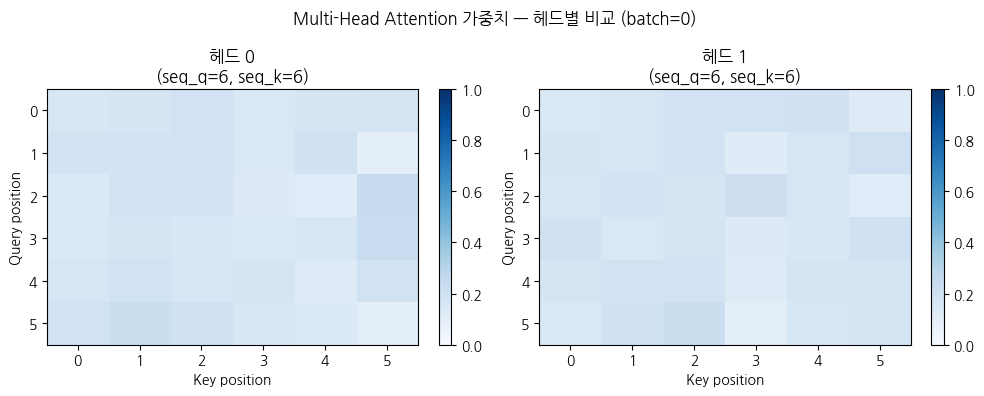

▶ 저장: figures/multihead_attention.png
▶ 각 헤드가 서로 다른 패턴에 주목하는지 확인


In [116]:
# ── 헤드별 Attention 가중치 시각화 ───────────────────────
# w_mha: (B, h, seq_q, seq_k) — 각 헤드가 어디를 주목하는지 비교
fig, axes = plt.subplots(1, NUM_HEADS, figsize=(5 * NUM_HEADS, 4))
if NUM_HEADS == 1:
    axes = [axes]

for h in range(NUM_HEADS):
    im = axes[h].imshow(
        w_mha[0, h].detach().numpy(),
        cmap='Blues', vmin=0, vmax=1, aspect='auto'
    )
    axes[h].set_title(f'헤드 {h}\n(seq_q={SRC_LEN}, seq_k={SRC_LEN})')
    axes[h].set_xlabel('Key position')
    axes[h].set_ylabel('Query position')
    plt.colorbar(im, ax=axes[h], fraction=0.046)

plt.suptitle(f'Multi-Head Attention 가중치 — 헤드별 비교 (batch=0)', fontsize=12)
plt.tight_layout()
plt.savefig("figures/multihead_attention.png", dpi=100)
plt.show()
print("▶ 저장: figures/multihead_attention.png")
print(f"▶ 각 헤드가 서로 다른 패턴에 주목하는지 확인")


## 5. Position-wise Feed-Forward Network (FFN)

### 📌 논문 Section 3.3, Equation (2)

$$\text{FFN}(x) = \max(0,\; xW_1 + b_1)\,W_2 + b_2$$

- 각 토큰 위치에 **독립적으로** 동일한 FFN을 적용 (위치 간 파라미터 공유)
- 내부 차원을 d_model → **4×d_model** → d_model로 확장했다가 줄임


In [117]:
class FeedForward(nn.Module):
    """
    nn.Sequential: 레이어를 순서대로 실행하는 컨테이너.
    nn.ReLU():     max(0, x) 활성화 함수.
    nn.Dropout(p): 훈련 시 p 확률로 원소를 0으로 설정 (regularization).
                   model.eval() 시 자동 비활성화.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),   # W_1: d_model → d_ff
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),   # W_2: d_ff → d_model
        )

    def forward(self, x):
        return self.net(x)

ffn = FeedForward(D_MODEL, D_FF, dropout=0.0)
x_in_ffn = torch.randn(BATCH, SRC_LEN, D_MODEL)

print("▶ FFN 입력  shape:", x_in_ffn.shape)                 # (2, 10, 512)

# 단계별 shape 추적
with torch.no_grad():
    after_W1   = ffn.net[0](x_in_ffn)   # Linear: d_model → d_ff
    after_relu = ffn.net[1](after_W1)   # ReLU
    after_W2   = ffn.net[3](after_relu) # Linear: d_ff → d_model

print(f"  Linear(512→2048) 후 : {after_W1.shape}")    # (2, 10, 2048)
print(f"  ReLU 후             : {after_relu.shape}")  # (2, 10, 2048)
print(f"  Linear(2048→512) 후: {after_W2.shape}")    # (2, 10, 512)

out_ffn = ffn(x_in_ffn)
print(f"\n▶ FFN 최종 출력 shape: {out_ffn.shape}")         # (2, 10, 512)


▶ FFN 입력  shape: torch.Size([2, 6, 16])
  Linear(512→2048) 후 : torch.Size([2, 6, 32])
  ReLU 후             : torch.Size([2, 6, 32])
  Linear(2048→512) 후: torch.Size([2, 6, 16])

▶ FFN 최종 출력 shape: torch.Size([2, 6, 16])


## 6. Encoder Layer

### 📌 논문 Section 3.1 (Encoder 부분)

각 Encoder 레이어는 두 개의 서브레이어로 구성된다.

```
x → [Multi-Head Self-Attention] → dropout → + x → LayerNorm  →  x'
x'→ [Feed-Forward Network]      → dropout → + x'→ LayerNorm  →  출력
```

**Add & Norm (Residual Connection + Layer Normalization)**
- **Residual**: gradient vanishing 방지, 학습 안정화
- **LayerNorm**: 배치 크기에 독립적, NLP에 적합

`nn.LayerNorm(d_model)`: 마지막 차원(d_model)에 대해 평균=0, 분산=1로 정규화


In [118]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        # LayerNorm: 각 서브레이어 뒤에 적용
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask=None, verbose=False):
        # ── 서브레이어 1: Multi-Head Self-Attention ───────
        # Self-Attention: Q = K = V = x
        attn_out, _ = _sdpa_quiet_mha(self.self_attn, x, x, x, src_mask)
        if verbose:
            print(f"  Self-Attn 출력 shape: {attn_out.shape}")
        # Add & Norm
        x = self.norm1(x + self.dropout(attn_out))
        if verbose:
            print(f"  Add&Norm1 후 shape: {x.shape}")

        # ── 서브레이어 2: Feed-Forward Network ────────────
        ffn_out = self.ffn(x)
        if verbose:
            print(f"  FFN 출력 shape: {ffn_out.shape}")
        # Add & Norm
        x = self.norm2(x + self.dropout(ffn_out))
        if verbose:
            print(f"  Add&Norm2 후 shape: {x.shape}")
        return x

def _sdpa_quiet_mha(mha_layer, Q, K, V, mask=None):
    """verbose 없이 MHA 호출하는 헬퍼"""
    B = Q.size(0)
    def split(t):
        B2, S, _ = t.size()
        return t.view(B2, S, mha_layer.num_heads, mha_layer.d_k).transpose(1, 2)
    Qp = split(mha_layer.W_q(Q))
    Kp = split(mha_layer.W_k(K))
    Vp = split(mha_layer.W_v(V))
    # mask는 make_padding_mask/make_causal_mask에서 이미 (B,1,1,S) 형태로 오므로
    # unsqueeze 불필요 — 그대로 _sdpa_quiet에 전달
    out, w = _sdpa_quiet(Qp, Kp, Vp, mask)
    out = out.transpose(1, 2).contiguous().view(B, -1, mha_layer.d_model)
    return mha_layer.W_o(out), w

enc_layer = EncoderLayer(D_MODEL, NUM_HEADS, D_FF, dropout=0.0)
x_enc = torch.randn(BATCH, SRC_LEN, D_MODEL)

print("▶ EncoderLayer 실행 (verbose=True):")
print(f"  입력 shape: {x_enc.shape}")
out_enc = enc_layer(x_enc, verbose=True)
print(f"\n▶ EncoderLayer 최종 출력 shape: {out_enc.shape}")  # (2, 10, 512)

# LayerNorm 효과 확인
print(f"\n▶ LayerNorm 효과 (마지막 차원 통계)")
print(f"  입력  mean={x_enc[0,0].mean():.4f}, std={x_enc[0,0].std():.4f}")
print(f"  출력  mean={out_enc[0,0].mean():.4f}, std={out_enc[0,0].std():.4f}")


▶ EncoderLayer 실행 (verbose=True):
  입력 shape: torch.Size([2, 6, 16])
  Self-Attn 출력 shape: torch.Size([2, 6, 16])
  Add&Norm1 후 shape: torch.Size([2, 6, 16])
  FFN 출력 shape: torch.Size([2, 6, 16])
  Add&Norm2 후 shape: torch.Size([2, 6, 16])

▶ EncoderLayer 최종 출력 shape: torch.Size([2, 6, 16])

▶ LayerNorm 효과 (마지막 차원 통계)
  입력  mean=-0.4572, std=1.0234
  출력  mean=-0.0000, std=1.0328


## 7. Decoder Layer

### 📌 논문 Section 3.1 (Decoder 부분)

Decoder 레이어는 **세 개의 서브레이어**로 구성된다.:

```
x   → [Masked Multi-Head Self-Attention]        → Add&Norm → x'
x'  → [Multi-Head Cross-Attention ← enc_output] → Add&Norm → x''
x'' → [Feed-Forward Network]                    → Add&Norm → 출력
```

| 어텐션 종류 | Q | K, V | 역할 |
|-------------|---|------|------|
| Masked Self-Attention | Decoder 현재 상태 | Decoder 현재 상태 | 미래 토큰 차단 (Causal Mask) |
| Cross-Attention       | Decoder 현재 상태 | **Encoder 출력** | 소스 시퀀스 참조 |


In [119]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads)  # Masked Self-Attn
        self.cross_attn = MultiHeadAttention(d_model, num_heads)  # Cross-Attn
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.norm3   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None, verbose=False):
        if verbose:
            print(f"  Decoder 입력 x       : {x.shape}")
            print(f"  Encoder 출력 enc_out : {enc_output.shape}")

        # ── 서브레이어 1: Masked Self-Attention ──────────
        # tgt_mask로 미래 토큰 차단 → 자동회귀(auto-regressive) 생성 보장
        attn1, _ = _sdpa_quiet_mha(self.self_attn, x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn1))
        if verbose:
            print(f"  Masked Self-Attn 후  : {x.shape}")

        # ── 서브레이어 2: Cross-Attention ─────────────────
        # Q: Decoder 상태   K, V: Encoder 출력
        # → "소스 시퀀스의 어느 부분에 주목할지" 학습
        attn2, cross_w = _sdpa_quiet_mha(self.cross_attn, x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn2))
        if verbose:
            print(f"  Cross-Attention 후   : {x.shape}")
            print(f"  Cross-Attn 가중치    : {cross_w.shape}  (B, h, tgt_len, src_len)")

        # ── 서브레이어 3: FFN ─────────────────────────────
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        if verbose:
            print(f"  FFN 후               : {x.shape}")
        return x

dec_layer = DecoderLayer(D_MODEL, NUM_HEADS, D_FF, dropout=0.0)
x_dec = torch.randn(BATCH, TGT_LEN, D_MODEL)
enc_out_dummy = torch.randn(BATCH, SRC_LEN, D_MODEL)

print("▶ DecoderLayer 실행 (verbose=True):")
out_dec = dec_layer(x_dec, enc_out_dummy, verbose=True)
print(f"\n▶ DecoderLayer 최종 출력 shape: {out_dec.shape}")   # (2, 8, 512)


▶ DecoderLayer 실행 (verbose=True):
  Decoder 입력 x       : torch.Size([2, 5, 16])
  Encoder 출력 enc_out : torch.Size([2, 6, 16])
  Masked Self-Attn 후  : torch.Size([2, 5, 16])
  Cross-Attention 후   : torch.Size([2, 5, 16])
  Cross-Attn 가중치    : torch.Size([2, 2, 5, 6])  (B, h, tgt_len, src_len)
  FFN 후               : torch.Size([2, 5, 16])

▶ DecoderLayer 최종 출력 shape: torch.Size([2, 5, 16])


## 8. 마스크(Mask) 생성

### 📌 논문 Section 3.2.3

| 마스크 | 목적 | 적용 위치 |
|--------|------|-----------|
| **Padding Mask** | `<PAD>` 토큰에 어텐션하지 않도록 차단 | Encoder Self-Attn, Decoder Cross-Attn |
| **Causal Mask** | 미래 토큰(i+1, i+2, ...)을 보지 못하도록 차단 | Decoder Masked Self-Attn |


In [120]:
# [broadcast 예시] 마스크를 어텐션 shape에 맞게 준비
#   attention scores : (2, 2, 6, 6)  ← (B, h, seq_q, seq_k)
#   padding mask     : (2, 1, 1, 6)  ← (B, 1,  1,    seq_k)  unsqueeze로 생성
#   causal mask      : (1, 1, 6, 6)  ← (1, 1, seq_q, seq_k)  unsqueeze로 생성
#   → 두 마스크 모두 (B, h, seq_q, seq_k)로 broadcast됨
def make_padding_mask(seq, pad_idx=0):
    """
    (seq == pad_idx): 원소별 비교 → PAD 위치가 True인 bool 텐서
    unsqueeze(1).unsqueeze(2): (B, S) → (B, 1, 1, S) 로 확장
        → MHA 내부에서 (B, h, seq_q, seq_k)에 브로드캐스팅 가능
    """
    return (seq == pad_idx).unsqueeze(1).unsqueeze(2)

def make_causal_mask(seq_len, device='cpu'):
    """
    torch.triu(mat, diagonal=1): 상삼각 행렬 (대각선 포함 안 함)
        → 위치 j > i 인 곳이 True (미래 위치)
    .bool(): uint8 → bool 타입 변환
    """
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
    return mask.unsqueeze(0).unsqueeze(0)   # (1, 1, seq_len, seq_len)

# ── Padding Mask 시각화 ───────────────────────────────────
src_with_pad = torch.tensor([
    [3, 7, 12, 0, 0],   # 마지막 두 토큰이 PAD
    [5, 9, 0,  0, 0],   # 마지막 세 토큰이 PAD
])
pad_mask = make_padding_mask(src_with_pad, pad_idx=0)

print("▶ 패딩 마스크")
print(f"  입력 src: {src_with_pad.tolist()}")
print(f"  mask shape: {pad_mask.shape}")                  # (2, 1, 1, 5)
print(f"  mask[0] (squeeze): {pad_mask[0].squeeze().tolist()}  (True=차단)")

# ── Causal Mask 시각화 ───────────────────────────────────
causal = make_causal_mask(6)
print(f"\n▶ Causal Mask (seq_len=6)")
print(f"  shape: {causal.shape}")                         # (1, 1, 6, 6)
print("  마스크 (True=미래 토큰, 어텐션 차단):")
for row in causal[0, 0].tolist():
    print("   ", ["■" if v else "□" for v in row])
print("  □=어텐션 허용  ■=어텐션 차단")


▶ 패딩 마스크
  입력 src: [[3, 7, 12, 0, 0], [5, 9, 0, 0, 0]]
  mask shape: torch.Size([2, 1, 1, 5])
  mask[0] (squeeze): [False, False, False, True, True]  (True=차단)

▶ Causal Mask (seq_len=6)
  shape: torch.Size([1, 1, 6, 6])
  마스크 (True=미래 토큰, 어텐션 차단):
    ['□', '■', '■', '■', '■', '■']
    ['□', '□', '■', '■', '■', '■']
    ['□', '□', '□', '■', '■', '■']
    ['□', '□', '□', '□', '■', '■']
    ['□', '□', '□', '□', '□', '■']
    ['□', '□', '□', '□', '□', '□']
  □=어텐션 허용  ■=어텐션 차단


## 9. Transformer 전체 모델

### 📌 논문 Figure 1 전체 아키텍처

모든 컴포넌트를 조합한 완성된 Transformer 모델


In [121]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.embedding   = nn.Embedding(vocab_size, d_model)
        self.scale       = math.sqrt(d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        # nn.ModuleList: Python list처럼 다루지만 파라미터를 PyTorch가 올바르게 추적
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, src, src_mask=None):
        # [broadcast 예시] 스칼라를 텐서 전체에 곱하기
        #   embedding(src) : (2, 6, 16)  ← (B, S, D_MODEL)
        #   self.scale     : scalar (= sqrt(D_MODEL))
        #   결과           : (2, 6, 16)  ← 모든 원소에 동일하게 곱함
        x = self.embedding(src) * self.scale
        x = self.pos_encoding(x)
        for i, layer in enumerate(self.layers):
            x = layer(x, src_mask)
        return self.norm(x)


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, d_model)
        self.scale        = math.sqrt(d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        x = self.embedding(tgt) * self.scale
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return self.norm(x)


class Transformer(nn.Module):
    """
    논문 기본 하이퍼파라미터:
        d_model=512, num_heads=8, num_layers=6, d_ff=2048, dropout=0.1
    """
    def __init__(self, src_vocab, tgt_vocab, d_model=512, num_heads=8,
                 num_layers=6, d_ff=2048, dropout=0.1, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.encoder = Encoder(src_vocab, d_model, num_heads, d_ff, num_layers, dropout)
        self.decoder = Decoder(tgt_vocab, d_model, num_heads, d_ff, num_layers, dropout)
        # 출력 투영: d_model → tgt_vocab_size 로짓
        self.output_proj = nn.Linear(d_model, tgt_vocab)
        self._init_weights()

    def _init_weights(self):
        """
        Xavier 균등 초기화 (논문 Section 5.4)
        nn.init.xavier_uniform_(p): in-place Xavier 초기화
            → var(W) = 2/(fan_in + fan_out) 조건으로 gradient 흐름 안정화
        p.dim() > 1: 1D 텐서(bias)는 초기화 제외
        """
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, verbose=False):
        device = src.device

        # 마스크 생성
        src_mask     = make_padding_mask(src, self.pad_idx).to(device)
        tgt_pad_mask = make_padding_mask(tgt, self.pad_idx).to(device)
        tgt_causal   = make_causal_mask(tgt.size(1), device)
        # [broadcast 예시] 다른 shape의 두 텐서를 OR 연산
        #   tgt_pad_mask : (2, 1, 1, 5)  ← (B, 1,  1,    tgt_len)
        #   tgt_causal   : (1, 1, 5, 5)  ← (1, 1, tgt_len, tgt_len)
        #   결과         : (2, 1, 5, 5)  ← 각 dim에서 큰 쪽으로 확장
        tgt_mask     = tgt_pad_mask | tgt_causal   # OR로 두 마스크 결합

        if verbose:
            print(f"  src shape      : {src.shape}")
            print(f"  tgt shape      : {tgt.shape}")
            print(f"  src_mask shape : {src_mask.shape}")
            print(f"  tgt_mask shape : {tgt_mask.shape}")

        enc_out = self.encoder(src, src_mask)
        if verbose:
            print(f"  enc_out shape  : {enc_out.shape}")

        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        if verbose:
            print(f"  dec_out shape  : {dec_out.shape}")

        logits = self.output_proj(dec_out)
        if verbose:
            print(f"  logits shape   : {logits.shape}")

        return logits


In [122]:
# ── 모델 생성 & 순전파 테스트 ────────────────────────────
model = Transformer(
    src_vocab=SRC_VOCAB, tgt_vocab=TGT_VOCAB,
    d_model=D_MODEL, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, d_ff=D_FF,
    dropout=0.1, pad_idx=PAD_IDX,
).to(device)

# p.numel(): 텐서의 전체 원소(파라미터) 수 반환
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"▶ 총 파라미터 수    : {total:,}")
print(f"▶ 학습 가능 파라미터: {trainable:,}")
print()

# 더미 입력 (PAD 포함)
src = torch.tensor([[3, 7, 12, 5, 9, 0, 0, 0, 0, 0],   # 뒤 4개 PAD
                     [1, 4, 8, 11, 0, 0, 0, 0, 0, 0]]).to(device)  # 뒤 6개 PAD
tgt = torch.randint(1, TGT_VOCAB, (BATCH, TGT_LEN)).to(device)

print("▶ Transformer 순전파 (verbose=True):")
model.eval()
with torch.no_grad():
    # torch.no_grad(): gradient 계산 비활성화 → 추론 시 메모리·속도 최적화
    logits = model(src, tgt, verbose=True)

print(f"\n▶ 최종 로짓 shape: {logits.shape}")     # (2, 8, 10000)
print(f"   └─ (batch={BATCH}, tgt_len={TGT_LEN}, vocab={TGT_VOCAB})")
print(f"\n▶ 첫 번째 토큰 상위 5개 예측 인덱스: {logits[0, 0].topk(5).indices.tolist()}")


▶ 총 파라미터 수    : 16,100
▶ 학습 가능 파라미터: 16,100

▶ Transformer 순전파 (verbose=True):
  src shape      : torch.Size([2, 10])
  tgt shape      : torch.Size([2, 5])
  src_mask shape : torch.Size([2, 1, 1, 10])
  tgt_mask shape : torch.Size([2, 1, 5, 5])
  enc_out shape  : torch.Size([2, 10, 16])
  dec_out shape  : torch.Size([2, 5, 16])
  logits shape   : torch.Size([2, 5, 100])

▶ 최종 로짓 shape: torch.Size([2, 5, 100])
   └─ (batch=2, tgt_len=5, vocab=100)

▶ 첫 번째 토큰 상위 5개 예측 인덱스: [18, 39, 63, 73, 19]


## 10. 학습 루프 미니 예시

### 📌 논문 Section 5.3 (Optimizer)

논문에서 사용한 **Noam Scheduler** (Warmup + 역제곱근 감소) 공식:

$$lrate = d_{\text{model}}^{-0.5} \cdot \min(step^{-0.5},\; step \cdot warmup\_steps^{-1.5})$$


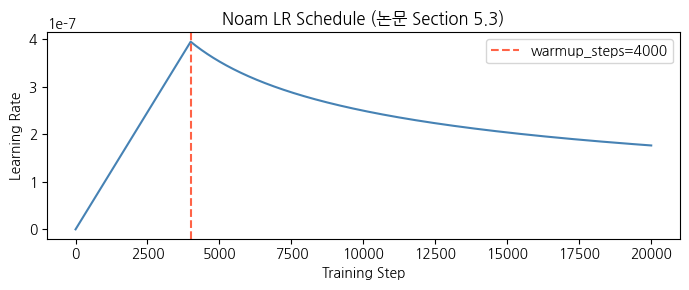

▶ warmup 구간: 선형 증가 → 이후: step^(-0.5)로 감소


In [123]:
# ── 손실 함수 & 옵티마이저 ───────────────────────────────
# nn.CrossEntropyLoss:
#   - 로짓 (B*T, V) + 정수 레이블 (B*T,) 를 받아 loss 계산
#   - ignore_index: PAD 위치의 loss를 무시
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

# torch.optim.Adam: 논문에서 사용한 옵티마이저 (β1=0.9, β2=0.98, ε=1e-9)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

# ── Noam Learning Rate Scheduler (논문 수식) ─────────────
def noam_lr(step, d_model, warmup_steps=4000):
    """
    step이 warmup_steps 이전: 선형 증가
    step이 warmup_steps 이후: 역제곱근 감소
    """
    step = max(step, 1)
    return d_model**(-0.5) * min(step**(-0.5), step * warmup_steps**(-1.5))

# LambdaLR: 람다 함수로 lr 배율 직접 지정
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda step: noam_lr(step, D_MODEL)
)

# LR 스케줄 시각화
steps = list(range(1, 20001))
lrs   = [noam_lr(s, D_MODEL) * 1e-4 for s in steps]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(steps, lrs, color='steelblue', linewidth=1.5)
ax.axvline(4000, color='tomato', linestyle='--', label='warmup_steps=4000')
ax.set_xlabel("Training Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Noam LR Schedule (논문 Section 5.3)")
ax.legend()
plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
plt.savefig("figures/lr_schedule.png", dpi=100)
plt.show()
print("▶ warmup 구간: 선형 증가 → 이후: step^(-0.5)로 감소")


In [124]:
# ── 미니 학습 루프 (3 스텝) ─────────────────────────────
model.train()
print("▶ 미니 학습 루프 실행:")
print(f"{'Step':>5} | {'Loss':>8} | {'LR':>12}")
print("-" * 35)

for step in range(1, 4):
    src_b = torch.randint(1, SRC_VOCAB, (BATCH, SRC_LEN)).to(device)
    tgt_b = torch.randint(1, TGT_VOCAB, (BATCH, TGT_LEN + 1)).to(device)

    # Teacher Forcing:
    #   입력: tgt[:, :-1]  (마지막 토큰 제외)
    #   레이블: tgt[:, 1:] (첫 토큰 제외 → 한 칸 앞 예측)
    tgt_input  = tgt_b[:, :-1]   # (B, TGT_LEN)
    tgt_label  = tgt_b[:, 1:]    # (B, TGT_LEN)

    # 순전파
    logits = model(src_b, tgt_input)  # (B, TGT_LEN, TGT_VOCAB)

    # 손실 계산
    # view(-1, TGT_VOCAB): (B, T, V) → (B*T, V)  CrossEntropyLoss 요구 형식
    # .view(-1): (B, T) → (B*T,)
    loss = criterion(logits.view(-1, TGT_VOCAB), tgt_label.reshape(-1))

    # 역전파
    optimizer.zero_grad()   # gradient 초기화 (누적 방지)
    loss.backward()         # 역전파: gradient 계산
    # gradient clipping: gradient norm이 1.0을 넘으면 스케일 다운 (학습 안정화)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()        # 파라미터 업데이트
    scheduler.step()        # LR 업데이트

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{step:>5} | {loss.item():>8.4f} | {current_lr:>12.8f}")

print("\n▶ 학습 루프 완료")
print(f"▶ logits shape 확인: {logits.shape}")  # (2, 8, 10000)


▶ 미니 학습 루프 실행:
 Step |     Loss |           LR
-----------------------------------
    1 |   5.0264 |   0.00000000
    2 |   4.7936 |   0.00000000
    3 |   4.8452 |   0.00000000

▶ 학습 루프 완료
▶ logits shape 확인: torch.Size([2, 5, 100])


## 📝 정리

| 컴포넌트 | 논문 위치 | 핵심 포인트 |
|----------|-----------|-------------|
| `scaled_dot_product_attention` | §3.2.1 Eq.(1) | `/ sqrt(d_k)` 스케일링으로 gradient 안정화 |
| `MultiHeadAttention` | §3.2.2 Eq.(4,5) | `split_heads` + `contiguous().view()` 로 헤드 분리·결합 |
| `FeedForward` | §3.3 Eq.(2) | 각 토큰 위치에 독립적으로 적용 |
| `PositionalEncoding` | §3.5 Eq.(3,4) | `register_buffer`로 학습 대상에서 제외 |
| `EncoderLayer` | §3.1 | Self-Attn + Add&Norm × 2 |
| `DecoderLayer` | §3.1 | Masked Self-Attn + Cross-Attn + Add&Norm × 3 |
| Causal Mask | §3.2.3 | `torch.triu` 상삼각 행렬로 미래 차단 |
| Noam Scheduler | §5.3 | Warmup → 역제곱근 감소 |

### 참고 자료
- [Attention Is All You Need (arXiv)](https://arxiv.org/abs/1706.03762)
- [The Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html)
- [PyTorch 공식 문서](https://pytorch.org/docs/)
